In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# Average plane Z positions
Z_DC31_X = -(10.3+7.3-1.7-4.7)/4.0
Z_DC31_Y = -(4.3+1.3-7.7-10.7)/4.0
Z_DC32_X = -(4.5+1.5)/2.0
Z_DC32_Y = -(-1.5-4.5)/2.0

# Detector Z positions
Z_DC31 = -271.5 # mm
Z_DC32 = 787.97 # mm
Z_SRPPAC = 0.0 # mm

spark = SparkSession.builder.master("local[10]").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

df = spark.read.parquet("/home/h487/notebooks/jan2026/srppac/parquet/run1083_joined_koji.parquet")
df.show(5)
print(f"Total events: {df.count()}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/29 11:32:50 WARN Utils: Your hostname, gpuana02, resolves to a loopback address: 127.0.1.1; using 133.11.152.134 instead (on interface enp4s0)
26/01/29 11:32:50 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
26/01/29 11:32:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


+---------+--------+-------------------+--------+------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-------------------+-------------------+-------------------+------------------+
|hbfNumber|sr_id0_x|           sr_pos_x|sr_id0_y|          sr_pos_y|dc31_x1_id0|dc31_x2_id0|dc31_y1_id0|dc31_y2_id0|dc31_x3_id0|dc31_x4_id0|dc31_y3_id0|dc31_y4_id0|dc32_x1_id0|dc32_x2_id0|dc32_y1_id0|dc32_y2_id0|             dc31_x|             dc31_y|             dc32_x|            dc32_y|
+---------+--------+-------------------+--------+------------------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-------------------+-------------------+-------------------+------------------+
|  5665953|      21| 10.869486999511718|      12|-10.61076337814331|         11|         11|         13|         13|        

Total entries: 9889, Underflow: 0, Inside: 9889, Overflow: 0
Total entries: 9889, Underflow: 0, Inside: 9889, Overflow: 0


(array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29., 30., 31.]),
 array([0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+01, 2.020e+02, 1.780e+02, 2.000e+00, 2.600e+01,
        8.590e+02, 1.277e+03, 9.700e+01, 1.173e+03, 1.173e+03, 1.201e+03,
        1.114e+03, 1.041e+03, 8.220e+02, 5.660e+02, 1.400e+02, 1.000e+00,
        1.000e+00, 3.000e+00, 3.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00]))

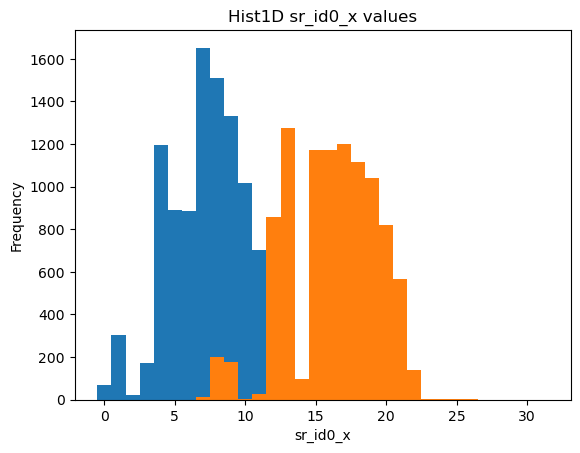

In [2]:
import matplotlib.pyplot as plt
from hist.sparkHist1d import Hist1D
Hist1D(df,"dc31_x1_id0", 17, [-0.5,15.5])
Hist1D(df,"sr_id0_x", 33, [-0.5,31.5])

Total entries: 9889, Underflow: 0, Inside: 9889, Overflow: 0
Total entries: 9889, Underflow: 0, Inside: 9889, Overflow: 0


(array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29., 30., 31.]),
 array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 159.,
        543., 800., 749., 193., 677., 807., 841., 835., 871., 785., 961.,
        797., 766.,  83.,  17.,   0.,   0.,   5.,   0.,   0.,   0.]))

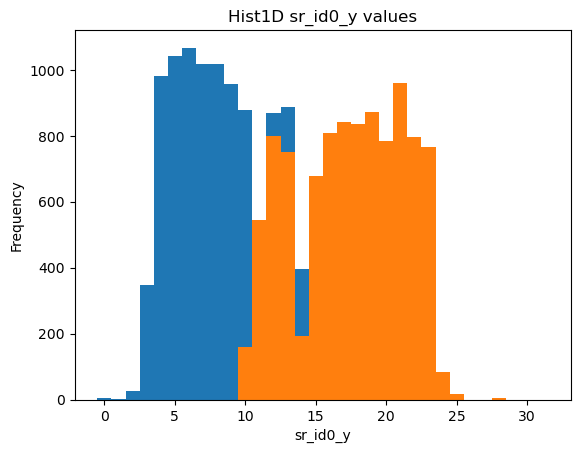

In [3]:
import matplotlib.pyplot as plt
from hist.sparkHist1d import Hist1D
Hist1D(df,"dc31_y1_id0", 17, [-0.5,15.5])
Hist1D(df,"sr_id0_y", 33, [-0.5,31.5])


In [4]:
L2X = Z_DC32 - Z_SRPPAC + Z_DC32_X
L2Y = Z_DC32 - Z_SRPPAC + Z_DC32_Y
L1X = Z_DC31 - Z_SRPPAC + Z_DC31_X
L1Y = Z_DC31 - Z_SRPPAC + Z_DC31_Y

df_chk = df.withColumn("interp_mwdc_x", F.expr(f"(dc31_x * {L2X} - dc32_x * {L1X})/(ABS({L1X}) + ABS({L2X}))")) \
           .withColumn("interp_mwdc_y", F.expr(f"(dc31_y * {L2Y} - dc32_y * {L1Y})/(ABS({L1Y}) + ABS({L2Y}))"))
df_chk.select("sr_pos_x", "interp_mwdc_x", "sr_pos_y", "interp_mwdc_y").show(20)

+-------------------+-------------------+-------------------+-------------------+
|           sr_pos_x|      interp_mwdc_x|           sr_pos_y|      interp_mwdc_y|
+-------------------+-------------------+-------------------+-------------------+
| 10.869486999511718| 11.465480299268858| -10.61076337814331|-16.069404741779326|
|-21.448645496368407| -21.18184483817579| -6.407026562690735|-11.755581663079983|
| 1.9913867592811583| 2.6157892804849547|  2.296221570968628| -2.985435830956741|
|-19.379605555534365|-18.865001908910855| 12.410609477758408|  6.763653917010207|
|   -9.6811652302742| -9.208456897534827| 10.471913642883301|  4.891605911393351|
|  -8.56179633140564| -7.855223300716359|-14.532064836025238|               NULL|
|  2.811081963777542|  3.369647631337791|  5.600066158771515|0.22388834428065627|
| 12.052851855754852|  12.82820690309199| 1.8096918034553529| -3.935552357193572|
|  9.637761723995208| 10.469575136481021| -4.744209591150284|-10.116840787145339|
| -8.79745414257

Statistics:
[[   0.    0.    0.]
 [   0. 9790.    0.]
 [   0.    0.    0.]]


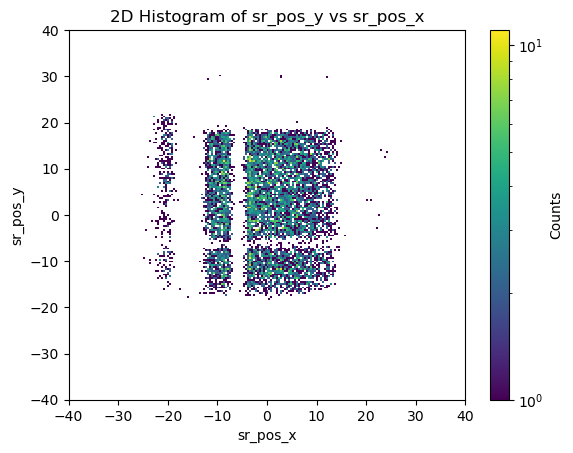

Statistics:
[[0.000e+00 1.000e+00 0.000e+00]
 [1.000e+00 9.804e+03 0.000e+00]
 [0.000e+00 9.000e+00 0.000e+00]]


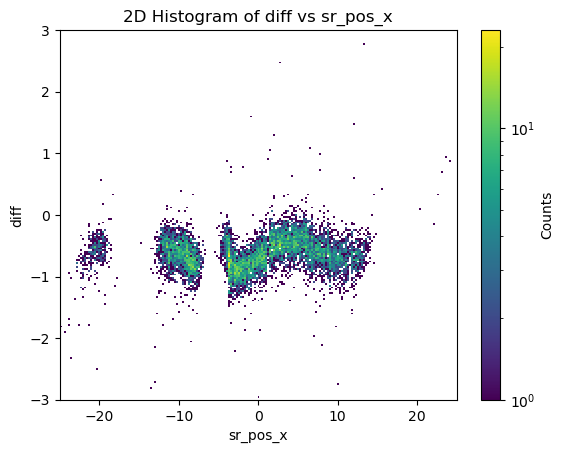

Statistics:
[[0.000e+00 2.000e+00 0.000e+00]
 [0.000e+00 9.772e+03 5.000e+00]
 [0.000e+00 3.000e+00 0.000e+00]]


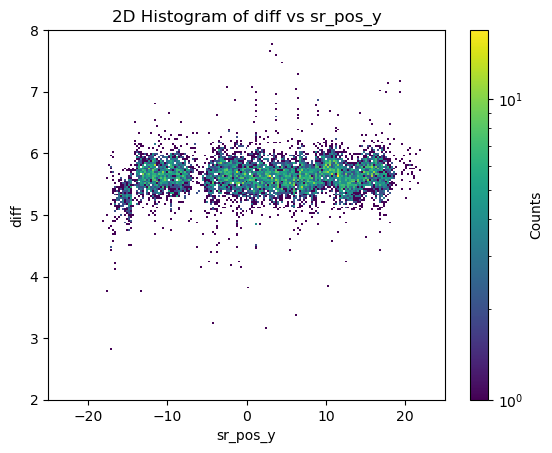

Total entries: 9824, Underflow: 9, Inside: 9814, Overflow: 1


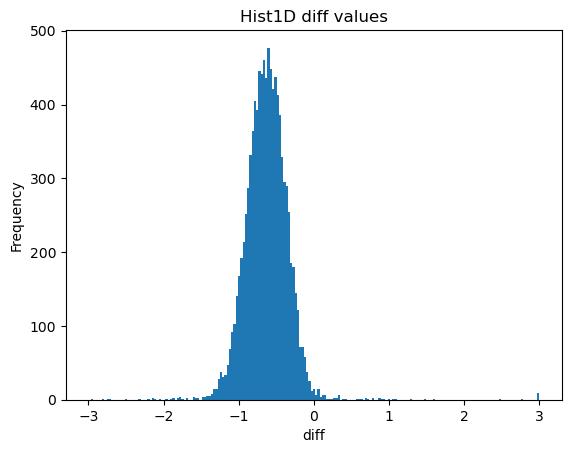

Total entries: 9785, Underflow: 3, Inside: 9780, Overflow: 2


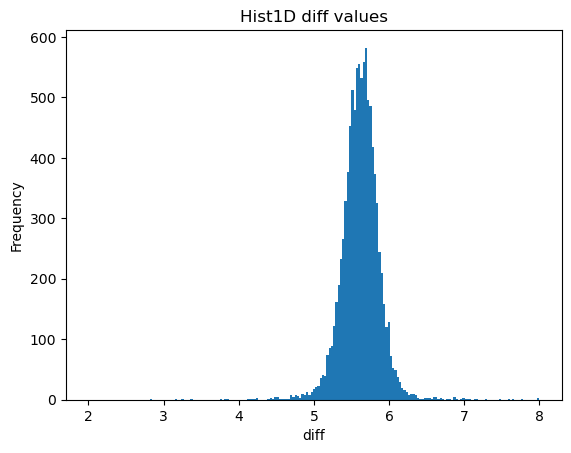

In [5]:
from hist.sparkHist2d import Hist2D
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt


h = Hist2D(df_chk, ["sr_pos_x", "sr_pos_y"], [200,200], [[-40,40], [-40,40]], norm=LogNorm(), interpolation='none')
plt.show()
h = Hist2D(df_chk.withColumn("diff", F.expr("sr_pos_x - interp_mwdc_x")), ["sr_pos_x", "diff"], [200,200], [[-25,25], [-3,3]], norm=LogNorm(), interpolation='none')
plt.show()
h = Hist2D(df_chk.withColumn("diff", F.expr("sr_pos_y - interp_mwdc_y")), ["sr_pos_y", "diff"], [200,200], [[-25,25], [2,8]], norm=LogNorm(), interpolation='none')
plt.show()

from hist.sparkHist1d import Hist1D
h = Hist1D(df_chk.withColumn("diff", F.expr("sr_pos_x - interp_mwdc_x")), "diff", 200, [-3,3])
plt.show()
h = Hist1D(df_chk.withColumn("diff", F.expr("sr_pos_y - interp_mwdc_y")), "diff", 200, [2,8])

Total entries: 9824, Underflow: 9, Inside: 9815, Overflow: 0


Output()

Output()

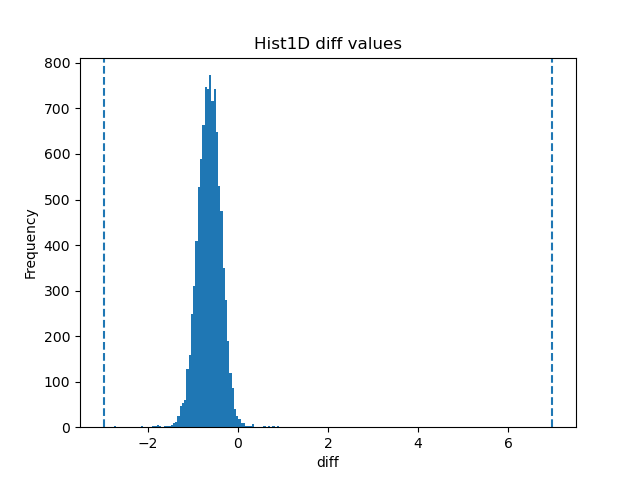

In [ ]:
%matplotlib widget

plt.clf()

from hist.sparkHist1d import Hist1D
Hist1D(df_chk.withColumn("diff", F.expr("sr_pos_x - interp_mwdc_x")), "diff", 200, [-3,7])

#from matplotlib import pyplot as plt
from hist.fitHist1d import FitHist1DGauss
FitHist1DGauss()
plt.show()

